In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
import sys
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
from linearmodels.panel import compare
from sklearn.metrics import r2_score, mean_squared_error
from shap.plots.colors._colors import red_blue

from config import get_config
from models.metrics import r2_score
from analysis.util import get_best_lambda_from_summary, get_lambda_list_for_horizon, load_and_average_ensemble_models, get_Xy_cbapm, get_Xy_real_concept, generate_ols_latex_table

In [2]:
def extract_all_last_layer_coefficients(horizon, results_dir='../results', checkpoints_dir='../checkpoints'):
    """
    Iterates over all weight_lambda and train_date for a given horizon,
    loads all ensemble members, averages the last layer weights and bias,
    and returns a list of dicts: {lambda, train_date, weights, bias} (averaged over ensemble)
    """
    train_dates = [
        '2011-01-01', '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01', 
        '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01'
        ]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_coeffs = []
    lambda_list = set(get_lambda_list_for_horizon(horizon, results_dir=results_dir))

    for weight_lambda in lambda_list:
        config = get_config(weight_lambda)
        for train_date in train_dates:
            model_dir = f'{checkpoints_dir}/{horizon}_{weight_lambda}'
            avg_weights, avg_bias = load_and_average_ensemble_models(model_dir, train_date, config, device)
            if avg_weights is not None:
                all_coeffs.append({
                    'lambda': weight_lambda,
                    'train_date': train_date,
                    'weights': avg_weights,
                    'bias': avg_bias
                })
    return all_coeffs

In [3]:
def plot_coeff_ranges(all_coeffs, variable_names, best_lambda, r2_by_period):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 15,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'lines.linewidth': 2,
        'lines.markersize': 7,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.7
    })
    
    cmap = red_blue
    weights = [d['weights'] for d in all_coeffs if d['lambda'] == best_lambda]
    weights = np.array(weights)
    if weights.ndim == 3:
        weights = weights[:, -1, :]  # Use last output (asset return)
    # Transpose to shape (n_vars, n_dates) for plotting
    weights_T = weights.T  # shape: (n_vars, n_dates)
    fig, ax = plt.subplots(figsize=(11, 6))
    # Normalize R^2 for colormap
    norm = plt.Normalize(vmin=np.min(r2_by_period), vmax=np.max(r2_by_period))
    for i, var in enumerate(variable_names):
        colors = cmap(norm(r2_by_period))
        ax.scatter(weights_T[i], np.full_like(weights_T[i], i+1), color=colors, s=60, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Coefficient Value', fontsize=14)
    ax.set_ylabel('Consensus Variables', fontsize=14)
    ax.set_yticks(np.arange(1, len(variable_names)+1))
    ax.set_yticklabels(variable_names, fontsize=12)
    ax.grid(axis='x', alpha=0.3, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    print(f'Coefficient Dot Plot (λ = {best_lambda})')
    # Add colorbar for R^2
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Out-of-Sample R²', fontsize=12)
    plt.tight_layout()
    plt.show()

In [4]:
def coefficients_analysis(horizon, best_lambda = None):
    # Load variable names (input features)
    data_path = f'../data/input_{horizon}.csv'
    input = pd.read_csv(data_path)
    input['date']  = pd.to_datetime(input['date'])
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input.columns)]
    variable_names = info[info['Cat.Data'] == 'Analyst']['LongDescription'].values

    # Extract all coefficients
    all_coeffs = extract_all_last_layer_coefficients(horizon)

    # Get best lambda from summary
    if best_lambda is None:
        best_lambda = get_best_lambda_from_summary(horizon)

    # Get r2 of best lambda from summary
    r2_path = f'../tables/{horizon}_r2_analysis_summary.xlsx'
    r2_df = pd.read_excel(r2_path, sheet_name='Period_Comparison')

    r2_by_period = r2_df['Best_R2'].values

    plot_coeff_ranges(
        all_coeffs,
        variable_names,
        best_lambda,
        r2_by_period
    )

In [5]:
def run_ols_regression(
    X,
    y,
    cov_type: str = 'kernel',     # Option A default: DK/HAC
    bandwidth: int = 11,          # MA(11) from overlapping 12m returns
    kernel: str = 'bartlett'
):
    """
    Option A: Pooled OLS on overlapping 12-month returns with overlap-robust inference.
    - No firm or time fixed effects (entity_effects=False, time_effects=False)
    - Driscoll–Kraay / kernel-HAC standard errors with Bartlett kernel and bandwidth=11
    - Memory-friendly float32 numerics
    """

    # --- checks ---
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame with 'date' and 'permno' columns.")
    if 'date' not in X or 'permno' not in X:
        raise ValueError("X must contain 'date' and 'permno' columns.")

    if isinstance(y, np.ndarray):
        y = pd.Series(y, index=X.index, name='y')
    elif isinstance(y, pd.Series):
        y = y.rename('y')
    else:
        raise ValueError("y must be a numpy array or pandas Series.")

    # --- assemble and clean ---
    df = X.copy()
    df['y'] = y

    id_cols = ['permno', 'date']
    reg_cols = [c for c in df.columns if c not in (id_cols + ['y'])]

    # Drop NAs only where needed (y or regressors)
    df = df.dropna(subset=['y'] + reg_cols)
    if df.empty:
        return {
            'coef': np.nan, 'bias': np.nan, 'r2': np.nan, 'mse': np.nan,
            'pvalues': np.nan, 'bias_pvalue': np.nan,
            'tvalues': np.nan, 'bias_tvalue': np.nan,
            'stderr': np.nan, 'bias_stderr': np.nan,
            'alpha_fe': None, 'gamma_fe': None,
            'n_samples': 0
        }

    # --- standardize dtypes & index ---
    df['permno'] = df['permno'].astype(str)
    df['date']   = pd.to_datetime(df['date'])

    df = df.set_index(['permno', 'date']).sort_index()
    df.index = df.index.set_names(['permno', 'date'])

    # memory-friendly numerics
    df[reg_cols + ['y']] = df[reg_cols + ['y']].astype(np.float32)

    y_dep  = df['y'].copy()
    X_exog = df[reg_cols].copy()

    # Add an explicit intercept for pooled OLS (since no FE are included)
    if 'const' not in X_exog.columns:
        X_exog = X_exog.assign(const=np.float32(1.0))
    else:
        X_exog['const'] = X_exog['const'].astype(np.float32)

    # force identical index names (safety)
    y_dep.index  = y_dep.index.set_names(['permno', 'date'])
    X_exog.index = X_exog.index.set_names(['permno', 'date'])

    # align exactly
    common_idx = y_dep.index.intersection(X_exog.index)
    y_dep  = y_dep.loc[common_idx]
    X_exog = X_exog.loc[common_idx]

    # --- pooled OLS (NO fixed effects) ---
    model = PanelOLS(y_dep, X_exog, entity_effects=False, time_effects=False)

    # --- inference choice ---
    if cov_type == 'kernel':
        # Driscoll–Kraay / kernel-HAC: robust to overlap (MA(11)) and x-sectional dep.
        results = model.fit(cov_type='kernel', kernel=kernel, bandwidth=bandwidth, debiased=True)
    elif cov_type == 'clustered':
        # Not recommended for overlapping long-horizon DV, but keep available
        results = model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
    else:
        raise ValueError("cov_type must be 'kernel' or 'clustered'.")

    # === METRICS — SAFE ALIGN/SQUEEZE ===
    y_pred = results.fitted_values
    try:
        y_pred.index = y_pred.index.set_names(['permno', 'date'])
    except Exception:
        pass
    y_pred = y_pred.reindex(y_dep.index)

    if isinstance(y_pred, pd.DataFrame):
        if y_pred.shape[1] == 1:
            y_pred = y_pred.iloc[:, 0]
        else:
            y_pred = y_pred.get('fitted', y_pred.iloc[:, 0])

    y_true_np = y_dep.to_numpy(dtype=np.float32)
    y_pred_np = y_pred.to_numpy(dtype=np.float32)

    r2  = np.float32(r2_score(y_true_np, y_pred_np))
    mse = np.float32(mean_squared_error(y_true_np, y_pred_np))

    # coefficients and inference (names preserved)
    params  = results.params.astype(np.float32)
    stderr  = results.std_errors.reindex(params.index).astype(np.float32)
    tstats  = results.tstats.reindex(params.index).astype(np.float32)
    pvals   = results.pvalues.reindex(params.index).astype(np.float32)

    # Separate intercept ("bias") from slopes
    bias         = float(params.get('const', np.nan))
    bias_stderr  = float(stderr.get('const', np.nan))
    bias_tvalue  = float(tstats.get('const', np.nan))
    bias_pvalue  = float(pvals.get('const', np.nan))

    coef   = params.drop(labels=['const'], errors='ignore')
    se     = stderr.drop(labels=['const'], errors='ignore')
    tvals  = tstats.drop(labels=['const'], errors='ignore')
    pvalues= pvals.drop(labels=['const'], errors='ignore')

    return {
        'coef': coef,                     # slope coefficients (pd.Series)
        'bias': bias,                     # intercept
        'r2': r2,
        'mse': mse,
        'pvalues': pvalues,
        'bias_pvalue': bias_pvalue,
        'tvalues': tvals,
        'bias_tvalue': bias_tvalue,
        'stderr': se,
        'bias_stderr': bias_stderr,
        'n_samples': int(len(common_idx))
    }

def rolling_regression(horizon, get_Xy_for_window, get_Xy_args=None, train_date='2020-01-01'):
    if get_Xy_args is None:
        get_Xy_args = {}
    results = []

    X, y = get_Xy_for_window(train_date, **get_Xy_args)
    reg_result = run_ols_regression(X, y)
    reg_result['train_date'] = train_date
    df = pd.DataFrame(reg_result)

    return df

def rolling_concept_regression_with_cbapm(horizon, weight_lambda, embedding_method):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input = pd.read_csv(f'../data/input_{horizon}.csv')
    target = pd.read_csv(f'../data/target_{horizon}.csv')
    input['date']  = pd.to_datetime(input['date'])
    target['date'] = pd.to_datetime(target['date'])
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input.columns)]
    config = get_config(weight_lambda)
    get_Xy_args = dict(input=input, target=target, info=info, config=config, device=device, horizon=horizon, weight_lambda=weight_lambda, embedding_method=embedding_method)
    return rolling_regression(horizon, get_Xy_cbapm, get_Xy_args)

def rolling_real_concept_regression(horizon):
    input = pd.read_csv(f'../data/input_{horizon}.csv')
    target = pd.read_csv(f'../data/target_{horizon}.csv')
    input['date']  = pd.to_datetime(input['date'])
    target['date'] = pd.to_datetime(target['date'])
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input.columns)]
    analyst_col = info[info['Cat.Data'] == 'Analyst']['Acronym'].values
    get_Xy_args = dict(input=input, target=target, analyst_col=analyst_col)
    return rolling_regression(horizon, get_Xy_real_concept, get_Xy_args)


Plotting Coefficients for 12-month prediction horizon
Coefficient Dot Plot (λ = 1.0)


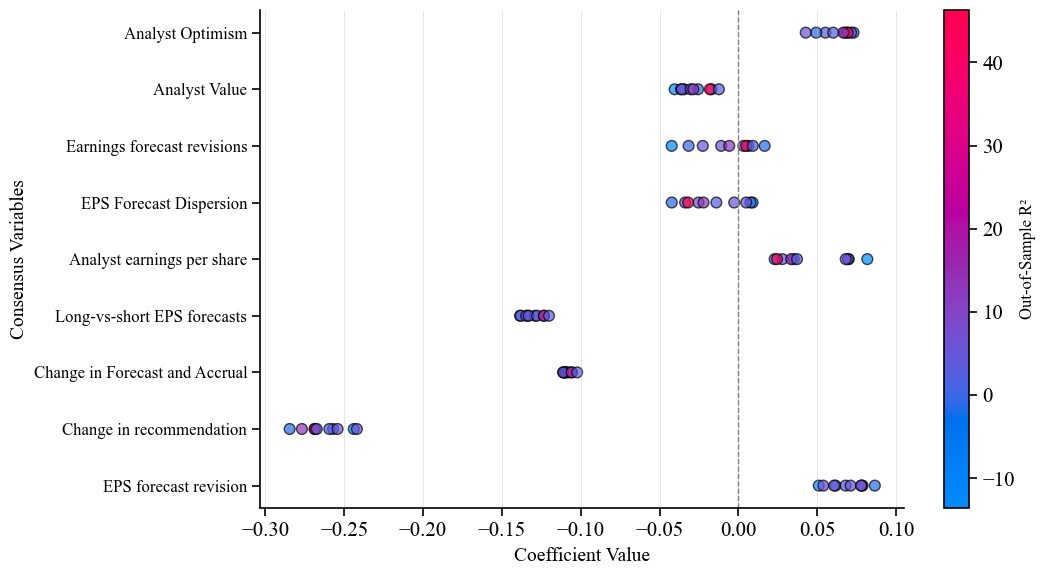

In [6]:
print("Plotting Coefficients for 12-month prediction horizon")
coefficients_analysis('12month', 1.0)

In [7]:
approx_summary = rolling_concept_regression_with_cbapm('12month', 1.0, 'autoencoder')
approx_summary

,coef,bias,r2,mse,pvalues,bias_pvalue,tvalues,bias_tvalue,stderr,bias_stderr,n_samples,train_date
AnalystRevision,0.116407,0.00052,8.35,0.236769,7.058604e-01,0.973977,0.377422,0.032621,0.308426,0.015936,510126,2020-01-01
ChangeInRecommendation,-3.907983,0.00052,8.35,0.236769,2.480927e-11,0.973977,-6.674640,0.032621,0.585497,0.015936,510126,2020-01-01
ChForecastAccrual,0.378108,0.00052,8.35,0.236769,1.251030e-01,0.973977,1.533705,0.032621,0.246532,0.015936,510126,2020-01-01
EarningsForecastDisparity,-0.093968,0.00052,8.35,0.236769,3.850795e-01,0.973977,-0.868576,0.032621,0.108186,0.015936,510126,2020-01-01
FEPS,0.317422,0.00052,8.35,0.236769,8.207987e-06,0.973977,4.459732,0.032621,0.071175,0.015936,510126,2020-01-01
ForecastDispersion,-0.626262,0.00052,8.35,0.236769,1.132575e-06,0.973977,-4.867142,0.032621,0.128671,0.015936,510126,2020-01-01
REV6,-0.332776,0.00052,8.35,0.236769,6.922677e-02,0.973977,-1.816941,0.032621,0.183152,0.015936,510126,2020-01-01
AnalystValue,-0.136357,0.00052,8.35,0.236769,6.021970e-03,0.973977,-2.746594,0.032621,0.049646,0.015936,510126,2020-01-01
AOP,0.124992,0.00052,8.35,0.236769,1.202325e-01,0.973977,1.553801,0.032621,0.080443,0.015936,510126,2020-01-01


In [8]:
real_summary = rolling_real_concept_regression('12month')
real_summary

,coef,bias,r2,mse,pvalues,bias_pvalue,tvalues,bias_tvalue,stderr,bias_stderr,n_samples,train_date
AnalystRevision,-0.004853,-0.006444,0.4,0.257303,0.189663,0.840769,-1.311578,-0.20091,0.003700,0.032076,510126,2020-01-01
ChangeInRecommendation,0.030686,-0.006444,0.4,0.257303,0.000000,0.840769,11.544157,-0.20091,0.002658,0.032076,510126,2020-01-01
ChForecastAccrual,0.039754,-0.006444,0.4,0.257303,0.000000,0.840769,8.570290,-0.20091,0.004639,0.032076,510126,2020-01-01
EarningsForecastDisparity,0.000232,-0.006444,0.4,0.257303,0.968920,0.840769,0.038963,-0.20091,0.005943,0.032076,510126,2020-01-01
FEPS,-0.024026,-0.006444,0.4,0.257303,0.102229,0.840769,-1.634146,-0.20091,0.014703,0.032076,510126,2020-01-01
ForecastDispersion,0.007622,-0.006444,0.4,0.257303,0.552204,0.840769,0.594460,-0.20091,0.012822,0.032076,510126,2020-01-01
REV6,-0.006819,-0.006444,0.4,0.257303,0.535374,0.840769,-0.619825,-0.20091,0.011001,0.032076,510126,2020-01-01
AnalystValue,0.014567,-0.006444,0.4,0.257303,0.379096,0.840769,0.879563,-0.20091,0.016561,0.032076,510126,2020-01-01
AOP,0.021581,-0.006444,0.4,0.257303,0.017780,0.840769,2.370171,-0.20091,0.009105,0.032076,510126,2020-01-01


In [9]:
input = pd.read_csv(f'../data/input_12month.csv')
signal_info = pd.read_csv('../data/info/SignalDoc.csv')
info = signal_info[signal_info['Acronym'].isin(input.columns)]
variable_names = info[info['Cat.Data'] == 'Analyst']['LongDescription'].values

latex_table = generate_ols_latex_table(real_summary, approx_summary, variable_names)
print(latex_table)


        \begin{table}[htbp]
            \centering
            \small
            \renewcommand{\arraystretch}{1.3}
            \setlength{\tabcolsep}{6pt}

             \caption{OLS regressions with raw versus model-inferred consensus. \\
            This table reports pooled OLS regressions in which the dependent variable is the \emph{annual} stock return \(R_{i,t+12}\). We compare specifications that use raw analyst consensus variables to those that use CB-APM–inferred consensus estimates at ($\lambda=1$), evaluated on the longest training set from the expanding-window procedure. The CB-APM consensus corresponds to the averaged output of an ensemble of models. Panel~A reports coefficient estimates, $t$-statistics, and predictor-level $R^2$ for each variable, while Panel~B summarizes the intercept, its standard error, and the overall in-sample adjusted $R^2$.}
            \label{tab:ols-consensus}

            \textbf{Panel A. Coefficients and t-statistics} \\
            \vspace{0.